# Data Exploration

## Data gathering
First of all, main libraries and training data are imported

In [718]:
#Import main libraries
import pandas
import numpy 
import matplotlib.pyplot as plot
import seaborn as sns
from sklearn.preprocessing import scale, robust_scale
#machine learning methods
from sklearn import tree
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, BaggingClassifier, VotingClassifier, BaggingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, ElasticNet
from sklearn import cross_validation, svm
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from scipy import stats
from IPython.display import display, HTML


%matplotlib inline
pandas.options.display.mpl_style = 'default'

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython.display import Image

DISPLAY_MAX_ROWS = 8  # number of max rows to print for a DataFrame
pandas.set_option('display.max_rows', DISPLAY_MAX_ROWS)


#Import training data set
raw_data = pandas.read_csv('training_set.csv')
raw_data

,user_id,install_date,country,device,session_count,ttp,last_moment,unit_count,revenue,try_1,try_2,try_3,win_1,win_2,win_3,days_active
0,D397PW-HC4XQE-19UNBO,2016-10-01,TR,iPhone,1,180,1475353329,NaN,NaN,0,4,0,0,3,0,4
1,VG7AJ8-AVN67M-MV934W,2016-10-01,CN,iPhone,1,400,1475351338,NaN,NaN,0,16,0,0,1,0,1
2,1PU8LJ-3048EC-GW2D3R,2016-10-02,US,iPad,3,1277,1475450107,NaN,NaN,8,21,1,8,14,1,5
3,9I6ZMT-92T6Y0-SZ5W96,2016-10-02,TR,iPhone,9,2407,1475443148,NaN,NaN,1,27,6,1,21,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6996,WO0KSX-KAEBDU-EDKNO9,2016-10-01,US,iPhone,2,1119,1475360207,NaN,NaN,4,9,0,4,9,0,3
6997,BFKROV-Z527AF-5LNVPW,2016-10-01,US,iPhone,2,3396,1475292574,NaN,NaN,11,30,0,5,12,0,3
6998,TX8Y2S-850LMQ-C2XDQU,2016-10-01,US,iPhone,1,6,1475328534,NaN,NaN,0,0,0,0,0,0,1
6999,2REOX1-Q7I9WV-QVSUC1,2016-10-01,BR,NaN,2,3502,1475320393,NaN,NaN,1,41,0,1,14,0,2


## Pre-Processing
A first look on the data allows us to notice that some pre-processing. I'll create a new data set, which will actually be used for the analysis and also set its index to be the user_id.


In [505]:
data = raw_data.copy()
data.set_index('user_id', inplace=True)

- First of all, I'll decode countries and devices into integers. To do so, I find out what are all of the possible values:

In [506]:
pandas.value_counts(data["device"])
pandas.value_counts(data["country"])

iPhone        5301
iPad          1454
iPod touch     207
Name: device, dtype: int64

US    3841
GB     939
FR     912
TR     617
BR     498
CN     171
Name: country, dtype: int64

From the data above we create our categories ranging from 1 to 3 for the devices and from 1 to 6 for countries. Zero will be used for the NaN values.

In [507]:
#Define a generic function using Pandas replace function
def coding(col, codeDict):
  colCoded = pandas.Series(col, copy=True)
  for key, value in codeDict.items():
    colCoded.replace(key, value, inplace=True)
  return colCoded

data["device"] = coding(data["device"], {'iPhone':1,'iPad':2, 'iPod touch':3})
data["device"].fillna(0, inplace=True)
data["country"] = coding(data["country"], {'US':1,'GB':2, 'FR':3, 'TR':4, 'BR':5, 'CN':6})
data["country"].fillna(0, inplace=True)

- Then, both install_date and last_moment must be transformed in readable time. I started with install_date and observed its range:

In [508]:
data['install_date'] = pandas.to_datetime(data['install_date'],infer_datetime_format=True)
data['install_date'].min()
data['install_date'].max()

Timestamp('2016-10-01 00:00:00')

Timestamp('2016-10-02 00:00:00')

As this range is only 2 day long, I chose to transform install_date in a integer variable representing the day in October 16 - 01st or 02.

In [509]:
data['install_date'] = data['install_date'].dt.day

Also, i set last_moment to the truncated hour in the local time of the user's country, so that we can
better observe the intra-day behavior of the users.

In [510]:
def local_time(x):
    if x['country'] == 1 :  timezone_diff= (-4*3600) # assuming GMT-5 for US, and that in october DST is +1
    elif x['country'] == 2: timezone_diff= (+1*3600) # assuming GMT+0 for GB, and that in october DST is +1
    elif x['country'] == 3: timezone_diff= (+2*3600) # assuming GMT+1 for FR, and that in october DST is +1
    elif x['country'] == 4: timezone_diff= (+3*3600) # assuming GMT+3 for TR
    elif x['country'] == 5: timezone_diff= (-3*3600) # assuming GMT-3 for BR
    elif x['country'] == 6: timezone_diff= (-4*3600) # assuming GMT-5 for CN, and that in october DST is +1    
    else: timezone_diff = 0
    
    local_time = pandas.to_datetime(x["last_moment"]+timezone_diff, unit='s') 
    local_time = local_time.hour
    return local_time

data['last_moment'] = data.apply(local_time, axis=1)

- Unit_count and revenue should not contain NaN values - this value means that the user did not made a in-app purchase,
so can be filled with zeroes.

In [511]:
data['unit_count'].fillna(0, inplace=True)
data['revenue'].fillna(0, inplace=True)

- Finally, as one of the variables we want to predict is whether the player will or not play at least one more day after the install, we should add it to your set:

In [512]:
data['greater_than']=data['days_active']

def is_greater_than1(x):
    if x > 1 : return 1
    else: return 0

data['greater_than']=data['days_active'].apply(is_greater_than1)

In [10]:
data

,install_date,country,device,session_count,ttp,last_moment,unit_count,revenue,try_1,try_2,try_3,win_1,win_2,win_3,days_active,greater_than
user_id,,,,,,,,,,,,,,,,
D397PW-HC4XQE-19UNBO,1,4,1,1,180,23,0,0,0,4,0,0,3,0,4,1
VG7AJ8-AVN67M-MV934W,1,6,1,1,400,15,0,0,0,16,0,0,1,0,1,0
1PU8LJ-3048EC-GW2D3R,2,1,2,3,1277,19,0,0,8,21,1,8,14,1,5,1
9I6ZMT-92T6Y0-SZ5W96,2,4,1,9,2407,0,0,0,1,27,6,1,21,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WO0KSX-KAEBDU-EDKNO9,1,1,1,2,1119,18,0,0,4,9,0,4,9,0,3,1
BFKROV-Z527AF-5LNVPW,1,1,1,2,3396,23,0,0,11,30,0,5,12,0,3,1
TX8Y2S-850LMQ-C2XDQU,1,1,1,1,6,9,0,0,0,0,0,0,0,0,1,0
2REOX1-Q7I9WV-QVSUC1,1,5,0,2,3502,8,0,0,1,41,0,1,14,0,2,1


# Preliminar Analysis
From my prior knowledge, I create a few hypothesis based on the given data set:

1. There should be a correlation between session_count and days_active (if a player plays many times in day 1 he should be prone to continue playing on day 2 and so on)
2. There should be a correlation between ttp and days_active(if a player plays a lot he should be more engaged to play again)
3. Unit count and revenue should be correlated, and both should correlate to the days_active (presuming purchases enhance engagement
to the game)
4. The number of tries and wins in each mode should be strongly correlated

5. There could be correlations between last_moment and days_active (behaviors such as 'early birds are less prone to continue playing' or 'nightly players continue playing more often' could exist)
6. There could be correlations of countries and days_active
7. There could be correlations of device and days_active
8. There should not be a strong correlation between the install_date and the days_active

## Hypothesis Testing
To test each hypothesis I'll do a scatterplot of the correlation and check its p-value

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdcb575c940>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8d780278>]], dtype=object)

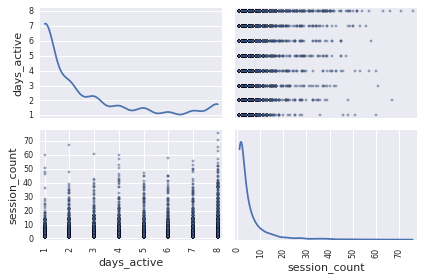

p-value:	 1.0
cor:		 nan


In [11]:
#Hypothesis 1 - Strong correlation between session_count and days_active
pandas.tools.plotting.scatter_matrix(data.loc[:, ['days_active', 'session_count']], diagonal="kde")
plot.tight_layout()
plot.show()

corr = stats.pearsonr(data['session_count'], data['days_active'])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

A simple Pearson test cannot determine a correlation between these two values.
Even though, we can notice from the scatter plot on the upper right that as the session_count raises, there are more chances that the user will have more than one active day.
We could, for instance, say that:
- if session_count is greater than 40 there are greater chances that the user has more than 2 days_active than that he has only 1;

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8d60ccf8>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8d4e1320>]], dtype=object)

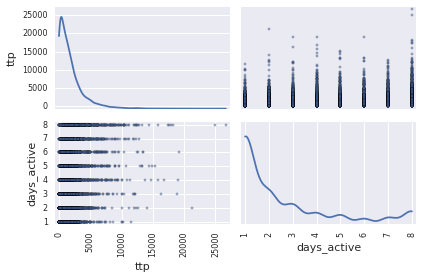

Ttp and Days Active
p-value:	 1.0
cor:		 nan


In [12]:
#Hypothesis 2 - Strong correlation between ttp and days_active
pandas.tools.plotting.scatter_matrix(data.loc[:, ['ttp', 'days_active']], diagonal="kde")
plot.tight_layout()
plot.show()
print('Ttp and Days Active')
corr = stats.pearsonr(data['ttp'], data['days_active'])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

A simple Pearson test cannot determine a correlation between these two values. Even though, we can notice from the scatter plot on the lower left that as the ttp raises, there are more chances that the user will have more than one active day. 
We could, for instance, say that:
if session_count is greater than 1000 there are greater chances that the user has more than 2 days_active than that he has only 1;


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8d5e3f98>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8d359358>]], dtype=object)

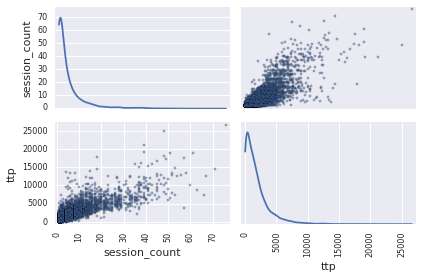

Session count versus ttp
p-value:	 1.0
cor:		 nan


In [13]:
#Correlation between session_count and ttp
pandas.tools.plotting.scatter_matrix(data.loc[:, [ 'session_count', 'ttp']], diagonal="kde")
plot.tight_layout()
plot.show()
print('Session count versus ttp')
corr = stats.pearsonr(data['session_count'], data['ttp'])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

Even though those to are not simply correlated by a Pearson test, there's clearly a tendance of accumulation for lower values of session_count and ttp (about session_count=30 and ttp=7000

From Hypothesis 1 and 2 scatter plots we can further notice that: 
- session_count is related to the days_active positively;
- session_count and ttp are more strongly correlated for their lower values, and they get sparse as ttp grow larger than 5000s or session_count is greater than 30, but correlation remains positive.

- if session_count is greater than 40 there are greater chances that the user has more than 2 days_active;
- if ttp is greater than 1500 the player has certainly more than 2 days_active

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8d3aea20>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8d046080>]], dtype=object)

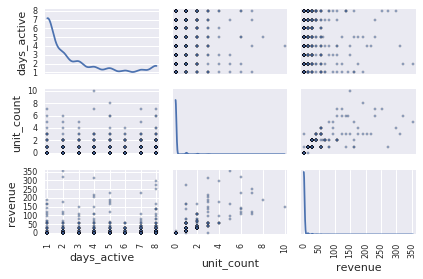

Revenue versus Unit Count
p-value:	 0.0
cor:		 0.806659657067

Revenue versus Days Active
p-value:	 1.50522614026e-10
cor:		 0.0764541291708

Unit count versus Days Active
p-value:	 1.47875372479e-20
cor:		 0.110768520815


In [14]:
#Hypothesis 3 - Strong correlation between unit_count, revenue, and of those with days_active
pandas.tools.plotting.scatter_matrix(data.loc[:, ['days_active', 'unit_count', 'revenue']], diagonal="kde")
plot.tight_layout()
plot.show()

print('Revenue versus Unit Count')
corr = stats.pearsonr(data['revenue'], data['unit_count'])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])
print('\nRevenue versus Days Active')
corr = stats.pearsonr(data['revenue'], data['days_active'])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

print('\nUnit count versus Days Active')
corr = stats.pearsonr(data['unit_count'], data['days_active'])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

The first part of this hypothesis is validated - the correlation between revenue and unit count being positive with a p-value close to zero.
On the other side, there is no direct correlation between either of them to the days_active variable.

Also, all p-values are small enough for us to conclude that the correlation values found are significant.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8d3743c8>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8c63f128>]], dtype=object)

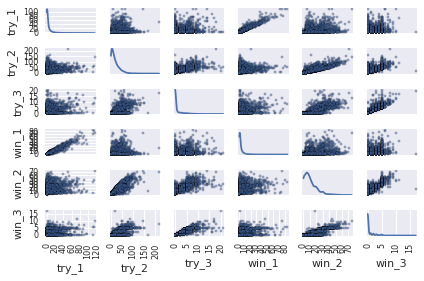

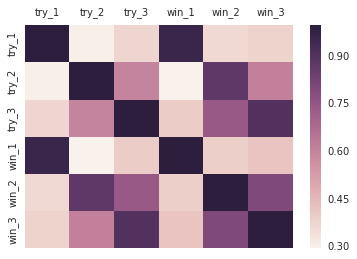

In [15]:
#Hypothesis 4 - Tries and Wins are correlated for all 3 types
pandas.tools.plotting.scatter_matrix(data.loc[:, ['try_1', 'try_2', 'try_3','win_1','win_2','win_3' ]], diagonal="kde")
plot.tight_layout()
plot.show()


corrmat = data.loc[:, ['try_1', 'try_2', 'try_3','win_1','win_2','win_3' ]].corr()
sns.heatmap(corrmat, vmax=1., square=False).xaxis.tick_top()

From the heatmap above we can se that, as expected, the stongest correlations are between each try and the respective win, followed by that between win_2 and win_3.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8c4ea208>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8a9a2828>]], dtype=object)

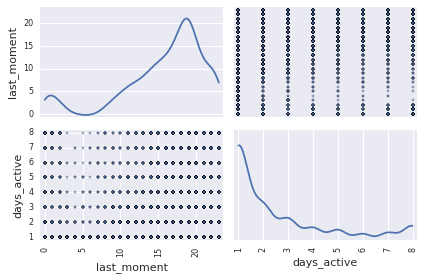

In [16]:
#Hypothesis 5 - Possible correlations between last_moment and days_active
pandas.tools.plotting.scatter_matrix(data.loc[:, ['last_moment', 'days_active']], diagonal="kde")
plot.tight_layout()
plot.show()

The data points are almost uniformly distributed, except for the local hours around 5 - where players seem to be less prone to play more than 4 days than players who stop playing at any other moment in the day.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8a922ef0>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8a8249b0>]], dtype=object)

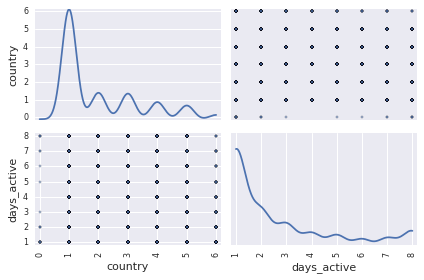

In [17]:
#Hypothesis 6 - Possible correlations between countries and days_active
pandas.tools.plotting.scatter_matrix(data.loc[:, ['country', 'days_active']], diagonal="kde")
plot.tight_layout()
plot.show()

There's no visible correlation between those variables.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8a7b9358>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8a6b5da0>]], dtype=object)

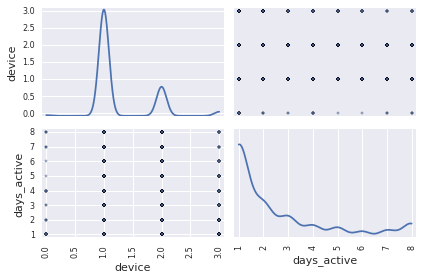

In [18]:
#Hypothesis 7 - Possible correlations between device and days_active
pandas.tools.plotting.scatter_matrix(data.loc[:, ['device', 'days_active']], diagonal="kde")
plot.tight_layout()
plot.show()

No clear correlations seem to be stablished between those two variables either.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8a5c6898>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x7fdc8a4ce390>]], dtype=object)

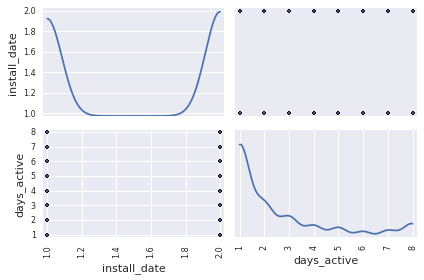

In [19]:
#Hypothesis 7 - Possible correlations between install_day and days_active
pandas.tools.plotting.scatter_matrix(data.loc[:, ['install_date', 'days_active']], diagonal="kde")
plot.tight_layout()
plot.show()

Again, no explicit correlation between the given variables.

# Overall Correlations
After this preliminary hypothesis testing, I've decided to run some basic data analysis on the whole sample to try and discover possibly meaningful patterns.

First of all, I started with a overall correlation heatmap and picked the strongest correlations. I decided to include the variables we want to predict in case there are any obvious tendances we might not have discovered on a prior analysis.

,FirstVariable,SecondVariable,Correlation
0,try_1,win_1,0.964875
1,try_3,win_3,0.911816
2,try_2,win_2,0.878776
3,ttp,try_2,0.842607
4,ttp,win_2,0.829796
5,session_count,ttp,0.808586
6,unit_count,revenue,0.806660
7,win_2,win_3,0.803646


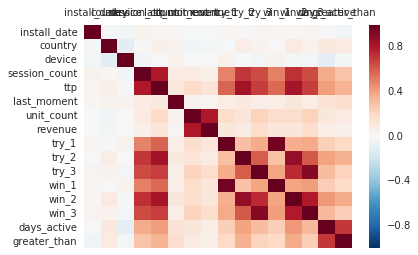

In [20]:
def mosthighlycorrelated(mydataframe, numtoreport):
    # find the correlations
    cormatrix = mydataframe.corr()
    # set the correlations on the diagonal or lower triangle to zero,
    # so they will not be reported as the highest ones:
    cormatrix *= numpy.tri(*cormatrix.values.shape, k=-1).T
    # find the top n correlations
    cormatrix = cormatrix.stack()
    cormatrix = cormatrix.reindex(cormatrix.abs().sort_values(ascending=False).index).reset_index()
    # assign human-friendly names
    cormatrix.columns = ["FirstVariable", "SecondVariable", "Correlation"]
    return cormatrix.head(numtoreport)

corrmat = data.corr()
sns.heatmap(corrmat, vmax=1., square=False).xaxis.tick_top()
mosthighlycorrelated(data, 8)

Results resemble to those obtained on our prior analysis - the pairs (try_i,win_i) share the most correlation, and same goes for (session_count,ttp) and (unit_count, revenue).
To add to our analysis, the pairs (ttp, try_2) - which is already correlated to win_2 as seen before, and (win_2, win_3).
As we can see, no simple correlation to days_active or greater_than was found with a corr > 0.81. 

# Testing

In [513]:
Y1 = data.loc[:, 'days_active']
Y2 = data.loc[:, 'greater_than']
X = data.loc[:, 'install_date':'win_3']
# In case any NaN values were left out, we replace them with zeroes for scaling.
Y1.fillna(0, inplace=True)
Y2.fillna(0, inplace=True)
X.fillna(0, inplace=True)

## Test with rules over a simple feature
Does some testing based on rules identified during first hypothesis testing.

The rules here will be written in terms of 'if field A's value is greater than B, then greater_than field equals 1';
The tests will be done in the following way:
We'll admit that for the all rows that fall into that rule the value is 1 and then calculate the absolute error generated from that suposition.

This will be done with the following functions:

In [294]:
#Defines rules for simple testing
def prediction(x, a):
    if x>=a: return 1
    else: return 0

def prediction2(x, a):
    if x < a: return 0
    else: return 1

def test_prediction(X, Y, a, field_name):
    subX = X.loc[ X[field_name] >= a ]
    y = subX[field_name].apply(prediction, args=(a,))
    err = abs(y - Y)*abs(y - Y)
    #print( 'Total wrong guesses:')
    #err.sum()
    #print( 'Total tries:')
    total_tries = err.count()
    #print('Accuracy:')
    accuracy =  round(1-  err.sum() / err.count(), 4)
    #print(accuracy)
    return accuracy, total_tries

def test_prediction2(X, Y, a, field_name):
    subX = X.loc[ X[field_name] < a ]
    y = subX[field_name].apply(prediction2, args=(a,))
    err = abs(y - Y)*abs(y - Y)
    #print( 'Total wrong guesses:')
    #err.sum()
    #print( 'Total tries:')
    total_tries = err.count()
    #print('Accuracy:')
    accuracy =  round(1-  err.sum() / err.count(), 4)
    #print(accuracy)
    return accuracy, total_tries

In [295]:
#Prediction test 1, based on hypothesis 1 (session_count)
a = [30, 20,15,14, 13, 12, 11, 10, 5]
field_name = 'session_count'

print('Tests for the positive {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction(X, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))
    
a = [0,1,2,3,4,5,6,7,8,9,10]
print('Tests for the negative {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction2(X, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

Tests for the positive session_count
30 - acc=0.9695 ; tries =  164
20 - acc=0.9669 ; tries =  362
15 - acc=0.9603 ; tries =  579
14 - acc=0.9566 ; tries =  645
13 - acc=0.9428 ; tries =  734
12 - acc=0.9425 ; tries =  800
11 - acc=0.9365 ; tries =  929
10 - acc=0.9293 ; tries =  1046
5 - acc=0.8648 ; tries =  2307
Tests for the negative session_count
0 - acc=nan ; tries =  0
1 - acc=0.3939 ; tries =  33
2 - acc=0.6009 ; tries =  2265
3 - acc=0.5371 ; tries =  3400
4 - acc=0.4961 ; tries =  4154
5 - acc=0.462 ; tries =  4693
6 - acc=0.4447 ; tries =  5091
7 - acc=0.4313 ; tries =  5384
8 - acc=0.4199 ; tries =  5620
9 - acc=0.4116 ; tries =  5811
10 - acc=0.4041 ; tries =  5954


This means that with a session_count rule for greater_than we could predict with more than 95% of the cases where its value is greater than 20 and, even in the cases where it is greater than 5 we could predict with an accuracy of more than 85%.
For the negative form (session_count smaller than X) there's no value that has more than 80% accuracy within this dataset.


In [301]:
#Prediction test 2, based on hypothesis 2
a = [3000, 2000, 1500, 1000, 800, 500, 300]
field_name = 'ttp'

print('Tests for {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction(X, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))
    
a = [0,100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
print('Tests for the negative {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction2(X, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

Tests for ttp
3000 - acc=0.9249 ; tries =  1278
2000 - acc=0.8765 ; tries =  2219
1500 - acc=0.8397 ; tries =  2963
1000 - acc=0.801 ; tries =  3939
800 - acc=0.7852 ; tries =  4338
500 - acc=0.7605 ; tries =  4985
300 - acc=0.736 ; tries =  5545
Tests for the negative ttp
0 - acc=nan ; tries =  0
100 - acc=0.8034 ; tries =  895
200 - acc=0.7464 ; tries =  1175
300 - acc=0.6983 ; tries =  1455
400 - acc=0.6661 ; tries =  1746
500 - acc=0.6382 ; tries =  2015
600 - acc=0.6187 ; tries =  2232
700 - acc=0.5994 ; tries =  2454
800 - acc=0.5815 ; tries =  2662
900 - acc=0.571 ; tries =  2867
1000 - acc=0.5541 ; tries =  3061


Accuracy is a little lower than for the last rule, but it can still be used to compound rules when values are over even 1000 if we accept the accuracy of this single field to be as low as 80%.
For the samples with the ttp smaller than 100 we also get an accuracy close to 80%.


# Feature Selection

Add here an explanation on the technique and on why a Logistic Regression was chosen.

In [377]:
#Using Recursive Feature Elimination
Xnp = numpy.array(X)
Ynp = numpy.array(Y1)
Idx = Y1.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.3)

model = LogisticRegression()
rfe = RFE(model, 3)

rfe.fit(X_train, y_train)

rfe.n_features_
rfe.support_
rfe.ranking_
list(X)

RFE(estimator=LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False),
  estimator_params=None, n_features_to_select=3, step=1, verbose=0)

3

array([False, False,  True, False,  True, False, False, False, False,
       False, False, False,  True, False], dtype=bool)

array([ 7,  8,  1,  5,  1,  2,  3, 12, 11,  4,  9, 10,  1,  6])

['install_date',
 'country',
 'device',
 'session_count',
 'ttp',
 'last_moment',
 'unit_count',
 'revenue',
 'try_1',
 'try_2',
 'try_3',
 'win_1',
 'win_2',
 'win_3']

array([12, 11,  2,  1,  1,  6, 10,  9,  5,  8,  7,  4,  1,  3])
array([ 7,  8,  1,  5,  1,  2,  3, 12, 11,  4,  9, 10,  1,  6])

From this method, the features to be selected should be, in order:
- Ttp, win_2, win_3
- Device
- Session_count
- Try_3
- Try_2
- Try_1
And so on.

As we know that the 'wins x tries' are highly correlated, we'll repeat the analysis dropping those that are less important in this first step - that is, try_1, try_2, try_3.


In [378]:
#Using Recursive Feature Elimination - with reduced X
X_reduced = X.drop(['try_1', 'try_2', 'try_3'], axis=1)
Xnp = numpy.array(X_reduced)
Ynp = numpy.array(Y1)
Idx = Y1.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.3)

model = LogisticRegression()
rfe = RFE(model, 3)

rfe.fit(X_train, y_train)

rfe.n_features_
rfe.support_
rfe.ranking_
list(X_reduced)

RFE(estimator=LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False),
  estimator_params=None, n_features_to_select=3, step=1, verbose=0)

3

array([False, False,  True, False,  True, False, False, False, False,
        True, False], dtype=bool)

array([3, 6, 1, 5, 1, 2, 4, 9, 8, 1, 7])

['install_date',
 'country',
 'device',
 'session_count',
 'ttp',
 'last_moment',
 'unit_count',
 'revenue',
 'win_1',
 'win_2',
 'win_3']

array([9, 7, 1, 4, 1, 3, 6, 5, 8, 1, 2])

Now, the selected features would be:
- Session_count, ttp and win_2
- win_3
- last_moment
- revenue

Now, let's compare those results with the ones of a ExtraTreeClassifier.

In [379]:
#Using ExtraTreeClassifier
Xnp = numpy.array(X)
Ynp = numpy.array(Y1)
Idx = Y1.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.3)

ect = ExtraTreesClassifier()
ect.fit(X_train, y_train)
ect.feature_importances_
list(X)

ExtraTreesClassifier(bootstrap=False, class_weight=None, criterion='gini',
           max_depth=None, max_features='auto', max_leaf_nodes=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
           oob_score=False, random_state=None, verbose=0, warm_start=False)

array([ 0.03274148,  0.07153246,  0.03125875,  0.09770053,  0.17017144,
        0.13150457,  0.00877819,  0.00891512,  0.07541269,  0.13264687,
        0.03224935,  0.06703774,  0.11443571,  0.02561509])

['install_date',
 'country',
 'device',
 'session_count',
 'ttp',
 'last_moment',
 'unit_count',
 'revenue',
 'try_1',
 'try_2',
 'try_3',
 'win_1',
 'win_2',
 'win_3']

array([ 0.03212065,  0.07557813,  0.03679334,  0.09884025,  0.16546885,
        0.12288937,  0.00836153,  0.00944519,  0.07798043,  0.12961816,
        0.03287064,  0.06336658,  0.11831161,  0.02835527])

The scores above suggest a importance of:
- ttp
- last_moment
- try_2
- win_2
- session_count
- try_1.


We'll also use it with our reduced X matrix to see if the results resemble.

In [380]:
#Using ExtraTreeClassifier - with reduced X
X_reduced = X.drop(['try_1', 'try_2', 'try_3'], axis=1)
Xnp = numpy.array(X_reduced)
Ynp = numpy.array(Y1)
Idx = Y1.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.3)

ect = ExtraTreesClassifier()
ect.fit(X_train, y_train)
ect.feature_importances_
list(X_reduced)

ExtraTreesClassifier(bootstrap=False, class_weight=None, criterion='gini',
           max_depth=None, max_features='auto', max_leaf_nodes=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
           oob_score=False, random_state=None, verbose=0, warm_start=False)

array([ 0.03318682,  0.07352242,  0.03920653,  0.13411812,  0.22995232,
        0.15419182,  0.00995316,  0.01009191,  0.10667613,  0.16639336,
        0.04270741])

['install_date',
 'country',
 'device',
 'session_count',
 'ttp',
 'last_moment',
 'unit_count',
 'revenue',
 'win_1',
 'win_2',
 'win_3']

array([ 0.03520344,  0.07368525,  0.0437358 ,  0.12848669,  0.23791992,
        0.15105327,  0.01024021,  0.0097982 ,  0.10267406,  0.16688452,
        0.04031866])

And now the scores suggest:
- ttp
- last_moment
- win_2
- session_count
- revenue


- win_1

## Feature Selection Summary 
To summarize, a heatmap with the variable names alongside their scores:


,RFE,ECT,Average
0,,,
ttp,0.142857,0.229952,0.186405
win_2,0.142857,0.166393,0.154625
last_moment,0.126984,0.154192,0.140588
session_count,0.079365,0.134118,0.106742
device,0.142857,0.039207,0.091032
install_date,0.111111,0.033187,0.072149
win_1,0.031746,0.106676,0.069211


([<matplotlib.axis.XTick at 0x7f08d035fe48>,
 <a list of 3 Text xticklabel objects>)

([<matplotlib.axis.YTick at 0x7f08d3b1edd8>,
 <a list of 11 Text yticklabel objects>)

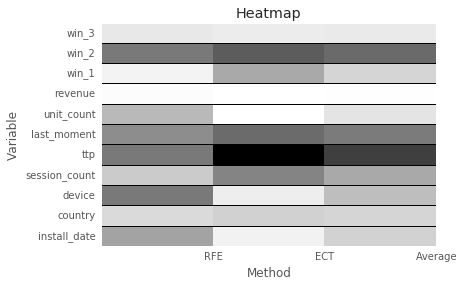

In [383]:
feature_names = numpy.array(list(X_reduced))
feature_names = feature_names.transpose()
features = pandas.DataFrame(feature_names)
features.set_index(0, inplace = True)

#RFE ranking must be normalized for comparizon
rfe_rank = rfe.ranking_
rfe_rank = 10 - rfe_rank
rfe_rank = rfe_rank / rfe_rank.sum()
features['RFE'] = rfe_rank

features['ECT'] = ect.feature_importances_
features['Average'] = (features['ECT']+features['RFE'])/2

features.nlargest(7, 'Average')

# Prints features selected
method_labels = numpy.array(list(features))
yticksposition = numpy.arange(len(features))
plot.pcolor(features)
plot.title('Heatmap')
plot.xlabel('Method')
plot.ylabel('Variable')
plot.xticks((1 , 2, 3) , method_labels)
plot.yticks( yticksposition+0.5, features.index)
plot.hlines(yticksposition, 0, 3)

From the above heatmap and list, we can see that considering the chosen methods for feature selection, the most relevant ones are:
- ttp
- win_2
- last_moment
- session_count
- device
- install_date
- win_1

We'll feed the regression methods with those variables instead of the whole ensemble.

In [514]:
# Reduction of X to the most important features:
X_reduced = X.loc[:, ['install_date','device', 'ttp', 'session_count', 'last_moment','win_1', 'win_2']]

In [515]:
X_reduced

,install_date,device,ttp,session_count,last_moment,win_1,win_2
user_id,,,,,,,
D397PW-HC4XQE-19UNBO,1,1,180,1,23,0,3
VG7AJ8-AVN67M-MV934W,1,1,400,1,15,0,1
1PU8LJ-3048EC-GW2D3R,2,2,1277,3,19,8,14
9I6ZMT-92T6Y0-SZ5W96,2,1,2407,9,0,1,21
...,...,...,...,...,...,...,...
WO0KSX-KAEBDU-EDKNO9,1,1,1119,2,18,4,9
BFKROV-Z527AF-5LNVPW,1,1,3396,2,23,5,12
TX8Y2S-850LMQ-C2XDQU,1,1,6,1,9,0,0
2REOX1-Q7I9WV-QVSUC1,1,0,3502,2,8,1,14


## Possible single feature rules:
After the choice of our features, it is important to check if there are no other simple rules based on those and standard deviations / quantiles.

## Hypothesis
There is a simple rule with each of the chosen features.
8. There are max/min rules based on win_2
9. There are max/min rules based on last_moment
10. There are max/min rules based on win_3


As we have already tested for session_count and ttp, we'll skip the test of those variables.

In [302]:
#Prediction test 3, based on hypothesis 9
a = [35, 30, 28, 26, 25, 24, 23, 21, 20, 15, 11, 9, 7, 3, 0]
field_name = 'win_2'

print('Tests for {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction(X_reduced, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

a = [0,1,2,3,4,5,6,7,8,9,10]
print('Tests for the negative {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction2(X_reduced, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

Tests for win_2
35 - acc=0.9563 ; tries =  252
30 - acc=0.9585 ; tries =  482
28 - acc=0.9564 ; tries =  551
26 - acc=0.9552 ; tries =  670
25 - acc=0.9509 ; tries =  713
24 - acc=0.9455 ; tries =  770
23 - acc=0.9361 ; tries =  861
21 - acc=0.9217 ; tries =  1086
20 - acc=0.9142 ; tries =  1200
15 - acc=0.8727 ; tries =  1925
11 - acc=0.8288 ; tries =  2880
9 - acc=0.8084 ; tries =  3418
7 - acc=0.7837 ; tries =  4152
3 - acc=0.726 ; tries =  5719
0 - acc=0.6457 ; tries =  7000
Tests for the negative win_2
0 - acc=nan ; tries =  0
1 - acc=0.8021 ; tries =  849
2 - acc=0.7574 ; tries =  1084
3 - acc=0.7127 ; tries =  1281
4 - acc=0.683 ; tries =  1527
5 - acc=0.6144 ; tries =  2132
6 - acc=0.587 ; tries =  2453
7 - acc=0.5555 ; tries =  2848
8 - acc=0.5388 ; tries =  3105
9 - acc=0.5095 ; tries =  3582
10 - acc=0.4897 ; tries =  3939


From the results, we can set two rules:
- One for win_2 > 20, with  91% accuracy
- One possible win_2 > 9 with a 80% accuracy
- One for win_2 < 1 with 80% accuracy

In [304]:
#Prediction test 4, based on hypothesis 10
a = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
field_name = 'last_moment'

print('Tests for {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction(X_reduced, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

a = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
print('Tests for the negative {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction2(X_reduced, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

Tests for last_moment
0 - acc=0.5783 ; tries =  5565
1 - acc=0.5779 ; tries =  5333
2 - acc=0.5814 ; tries =  5181
3 - acc=0.5859 ; tries =  5050
4 - acc=0.5912 ; tries =  4966
5 - acc=0.5971 ; tries =  4889
6 - acc=0.6026 ; tries =  4811
7 - acc=0.607 ; tries =  4748
8 - acc=0.6091 ; tries =  4674
9 - acc=0.6134 ; tries =  4565
10 - acc=0.6183 ; tries =  4404
11 - acc=0.6235 ; tries =  4221
12 - acc=0.6311 ; tries =  3987
13 - acc=0.6347 ; tries =  3748
14 - acc=0.6471 ; tries =  3508
15 - acc=0.6553 ; tries =  3203
16 - acc=0.6664 ; tries =  2878
17 - acc=0.6689 ; tries =  2546
18 - acc=0.6636 ; tries =  2203
19 - acc=0.6549 ; tries =  1782
20 - acc=0.6095 ; tries =  1196
21 - acc=0.6005 ; tries =  881
22 - acc=0.5875 ; tries =  606
23 - acc=0.5909 ; tries =  308
24 - acc=nan ; tries =  0
Tests for the negative last_moment
0 - acc=nan ; tries =  0
1 - acc=0.4138 ; tries =  232
2 - acc=0.4635 ; tries =  384
3 - acc=0.4971 ; tries =  515
4 - acc=0.5292 ; tries =  599
5 - acc=0.5577 ; t

None of the values provide an accuracy of more than 80%, so we should discard this rule.

In [309]:
#Prediction test 5, based on hypothesis 10
a = [0,1,2,3,4,5,6,7,8,9,10]
field_name = 'win_3'

print('Tests for {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction(X_reduced, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

a = [0,1,2,3,4,5,6,7,8,9,10]
print('Tests for the negative {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction2(X_reduced, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

Tests for win_3
0 - acc=0.5783 ; tries =  5565
1 - acc=0.7526 ; tries =  865
2 - acc=0.7835 ; tries =  425
3 - acc=0.8333 ; tries =  126
4 - acc=1.0 ; tries =  15
5 - acc=1.0 ; tries =  5
6 - acc=nan ; tries =  0
7 - acc=nan ; tries =  0
8 - acc=nan ; tries =  0
9 - acc=nan ; tries =  0
10 - acc=nan ; tries =  0
Tests for the negative win_3
0 - acc=nan ; tries =  0
1 - acc=0.4538 ; tries =  4700
2 - acc=0.4387 ; tries =  5140
3 - acc=0.4277 ; tries =  5439
4 - acc=0.4229 ; tries =  5550
5 - acc=0.4221 ; tries =  5560
6 - acc=0.4217 ; tries =  5565
7 - acc=0.4217 ; tries =  5565
8 - acc=0.4217 ; tries =  5565
9 - acc=0.4217 ; tries =  5565
10 - acc=0.4217 ; tries =  5565


The results do not seem good enough. As this variable has a very high correlation to try_3, I'll also try a rule with this variable, even if it is not in our main features.

In [311]:
#Prediction test 6, based on hypothesis 10
a = [0,1,2,3,4,5,6,7,8,9,10]
field_name = 'try_3'

print('Tests for {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction(X, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

a = [0,1,2,3,4,5,6,7,8,9,10]
print('Tests for the negative {}'.format(field_name))
for item in a:
    accuracy, total_tries = test_prediction2(X, Y2, item, field_name)   
    print('{} - acc={} ; tries =  {}'.format(item, accuracy, total_tries))

Tests for try_3
0 - acc=0.6457 ; tries =  7000
1 - acc=0.8497 ; tries =  1843
2 - acc=0.8824 ; tries =  1361
3 - acc=0.9032 ; tries =  1054
4 - acc=0.9187 ; tries =  775
5 - acc=0.9361 ; tries =  579
6 - acc=0.9352 ; tries =  401
7 - acc=0.9468 ; tries =  263
8 - acc=0.9421 ; tries =  190
9 - acc=0.925 ; tries =  120
10 - acc=0.9333 ; tries =  75
Tests for the negative try_3
0 - acc=nan ; tries =  0
1 - acc=0.4272 ; tries =  5157
2 - acc=0.4114 ; tries =  5639
3 - acc=0.3999 ; tries =  5946
4 - acc=0.3883 ; tries =  6225
5 - acc=0.3805 ; tries =  6421
6 - acc=0.3719 ; tries =  6599
7 - acc=0.366 ; tries =  6737
8 - acc=0.3626 ; tries =  6810
9 - acc=0.3592 ; tries =  6880
10 - acc=0.3574 ; tries =  6925


This rule performs pretty well in it's positive formulation, with values over 3 representing an accuracy of more than 90%. 

# Rules wrap-up
After these studies, the rules we'll be using for a boolean decision of greater_than are:
- If session_count > 10, greater_than is True (with about 93% acc)
- If ttp > 3000, greater_than is True (with about 92% acc)
- If win_2 > 20, greater_than is True (with about 91% acc)
- If try_3 > 3, greater_than is True (with about 90% acc)
- If win_2 < 1, greater_than is False  (with about 80% acc)

# Machine learning tests

In this part, we'll test our data sets with some machine learning algorythms to find out the best one to use for prediction with the real test set.

## Data Setup
Here we prepare our variables for the tests.

In [516]:
data_filtered = data
Y1 = data_filtered.loc[:, 'days_active']
Y2 = data_filtered.loc[:, 'greater_than']
X = data_filtered.loc[:, 'install_date':'win_3']
# In case any NaN values were left out, we replace them with zeroes for scaling.
Y1.fillna(0, inplace=True)
Y2.fillna(0, inplace=True)
X.fillna(0, inplace=True)
X_reduced = X.loc[:, ['install_date','device', 'ttp', 'session_count', 'last_moment','win_1', 'win_2']]
# non-robust scaled version X_reduced = X.loc[:, ['ttp', 'session_count', 'last_moment','win_2', 'win_3' ]]
X_filtered = X_reduced.copy()

# Prediction of greater_than

## Regression Method Comparison
- Linear Regression
- Logistic Regression
- Decision Tree
- KNeighbors
- RandomForest

And then try out a Voting Classifier for the 2 with the highest accuracy scores.

In [488]:
#For Y = Y2
Xnp = numpy.array(X_filtered)
Ynp = numpy.array(Y2)
Idx = Y2.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.6)

clf1 = ('Linear', LinearRegression() )
clf2 = ('LogisticReg', LogisticRegression(penalty='l2', C=0.01))
clf3 = ('DecisionTree', tree.DecisionTreeClassifier())
clf4 = ('KNeighbors', KNeighborsClassifier(n_neighbors = 10, weights='distance', n_jobs=3))
clf5 = ('RandomForest', RandomForestClassifier())

clf_array = [clf1, clf2, clf3, clf4, clf5]
overall_accuracy = []

for clf in clf_array:
    # Training
    clf[1].fit(X_train, y_train)
    # Testing
    overall_accuracy.append( (clf[0], clf[1].score(X_test, y_test)) )

print('Accuracy for the first learning step:')
overall_accuracy
  

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

LogisticRegression(C=0.01, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None, min_samples_leaf=1,
            min_samples_split=2, min_weight_fraction_leaf=0.0,
            presort=False, random_state=None, splitter='best')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=3, n_neighbors=10, p=2,
           weights='distance')

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False)

Accuracy for the first learning step:


[('Linear', 0.1622696819683298),
 ('LogisticReg', 0.73261904761904761),
 ('DecisionTree', 0.65619047619047621),
 ('KNeighbors', 0.70785714285714285),
 ('RandomForest', 0.69714285714285718)]

From the above results, we will try the Voting Classifier with a Logistic Regression and a KNeighbors methods.
We'll then use the method between those three that has the better accuracy.

In [489]:
clf6 = ('Voting', VotingClassifier([clf2, clf4]))
clf6[1].fit(X_train, y_train)
overall_accuracy.append( (clf6[0], clf6[1].score(X_test, y_test)) )
overall_accuracy

VotingClassifier(estimators=[('LogisticReg', LogisticRegression(C=0.01, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)), ('KNeighbors', KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=3, n_neighbors=10, p=2,
           weights='distance'))],
         voting='hard', weights=None)

[('Linear', 0.1622696819683298),
 ('LogisticReg', 0.73261904761904761),
 ('DecisionTree', 0.65619047619047621),
 ('KNeighbors', 0.70785714285714285),
 ('RandomForest', 0.69714285714285718),
 ('Voting', 0.71857142857142853)]

As we can see, the Logistic Regression is still the  most accurate and we're gonna use it from now on on our main samples.

# Outlier removal
To try and enhance accuracy, we'll use a OneClassSVM to find outliers and remove them for a second learning round.

In [501]:
# First step Oultlier Removal
#Test for the whole dataset
outliers_fraction = 0.10
clf = svm.OneClassSVM(nu=0.95 * outliers_fraction + 0.05,
                                     kernel="rbf", gamma=0.1)
clf.fit(Xnp)
prediction = pandas.DataFrame(clf.predict(Xnp))

# Removal of outliers
X_filtered['is_outlier'] = prediction.values
Y2 = Y2.to_frame(name = 'days_active')
Y2['is_outlier'] = prediction.values

X_cleaned = X_filtered[ X_filtered['is_outlier'] == 1 ].copy()
X_outliers = X_filtered[ X_filtered['is_outlier'] == -1 ].copy()
X_cleaned.drop( ['is_outlier'], axis=1, inplace = True)
X_outliers.drop(['is_outlier'], axis=1, inplace = True)
X_filtered.drop( ['is_outlier'], axis=1, inplace = True)

# in the end of the process, Y variables should be pandas.Series objects;
Y2_cleaned = Y2[ Y2['is_outlier'] == 1].copy()
Y2_outliers = Y2[ Y2['is_outlier'] == -1].copy()
Y2_cleaned = Y2_cleaned.loc[:, 'days_active']
Y2_outliers = Y2_outliers.loc[:, 'days_active']
Y2 = Y2.loc[:, 'days_active']

sample_size_clean= len(X_cleaned)/len(X_filtered)
sample_size_outliers = len(X_outliers)/len(X_filtered)

OneClassSVM(cache_size=200, coef0=0.0, degree=3, gamma=0.1, kernel='rbf',
      max_iter=-1, nu=0.14500000000000002, random_state=None,
      shrinking=True, tol=0.001, verbose=False)

## Second Learning Round
We'll now repeat the learning procedure with the new X_cleaned and X_outliers data set.

In [502]:
#For Y = Y2
Xnp = numpy.array(X_cleaned)
Ynp = numpy.array(Y2_cleaned)
Idx = Y2_cleaned.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.6)

clf = LogisticRegression(penalty='l2', C=0.01)

# Training
clf.fit(X_train, y_train)
# Testing
accuracy_clean = clf.score(X_test, y_test)
print('Accuracy for the second learning step:')
accuracy_clean

LogisticRegression(C=0.01, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

Accuracy for the second learning step:


0.70219871973281378

For the outliers, as I expect them to be more sparse than the inliners, I'll chose a Bagged KNeighbors method instead of the Logistic Regression.

In [522]:
#For Y = Y2
Xnp = numpy.array(X_outliers)
Ynp = numpy.array(Y2_outliers)
Idx = Y2_outliers.index
Xnp = scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.6)

base = KNeighborsClassifier(n_neighbors = 10, weights='distance', n_jobs=3)
clf = BaggingClassifier(base_estimator=base, n_estimators=10) 
    
# Training
clf.fit(X_train, y_train)
# Testing
accuracy_outliers = clf.score(X_test, y_test)
print('Accuracy for the second learning step:')
accuracy_outliers

BaggingClassifier(base_estimator=KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=3, n_neighbors=10, p=2,
           weights='distance'),
         bootstrap=True, bootstrap_features=False, max_features=1.0,
         max_samples=1.0, n_estimators=10, n_jobs=1, oob_score=False,
         random_state=None, verbose=0, warm_start=False)

Accuracy for the second learning step:


0.87993421052631582

In [524]:
print('Accuracy with outlier separation:')
sample_size_clean*accuracy_clean+sample_size_outliers*accuracy_outliers

Accuracy with outlier separation:


0.73146542331685049

## Results
As we can see, no real gain in accuracy has been observed by separating the outliers. So, in our real case (with the test set being the one we will actually predict), I'll use a simple layer Logistic Regression after applying the rules - which have a much better accuracy than the Machine Learning process itself.

# Prediction of Days_active
For the days_active variable, we'll use a method that resembles to the one used in the prediction of greater_then - excepted the goal metric and the Machine Learning methods used, which will differ due to the nature of our variables.

In this case, Regressors and Classifiers will both be used on the test fase, to verify which have the best performance.


## Regression Method Comparison
- Linear Regression
- Logistic Regression
- Decision Tree
- KNeighbors Classifier and Regressor
- Bagged KNeighbors
- RandomForest Classifier and Regressor
- ExtraTrees Regressor and Classifier

As the voting technique showed no gain in our first analysis, we can safely assume that there's no gain in doing it with this second goal variable - given the dataset is the same, so will be dispersion and the computed votes should be so close as to give the same result - as seen before.

In [576]:
#For Y = Y1
Xnp = numpy.array(X_filtered)
Ynp = numpy.array(Y1)
Idx = Y1.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.6)

clf1 = ('Linear Regression', LinearRegression() )
clf2 = ('Logistic Regression', LogisticRegression(penalty='l2', C=0.01))
clf3 = ('DecisionTree', tree.DecisionTreeClassifier())
clf4 = ('KNeighbors Classifier', KNeighborsClassifier(n_neighbors = 10, weights='distance', n_jobs=3))
clf5 = ('KNeighbors Regressor', KNeighborsRegressor(n_neighbors = 10, weights='distance', n_jobs=3))
clf6 = ('RandomForest Regressor', RandomForestRegressor())
base = KNeighborsRegressor()
clf7 = ('Bagged KNeighbors', BaggingRegressor(base_estimator = base, n_estimators=100))
clf8 = ('Extra Trees Regressor', ExtraTreesRegressor(n_estimators=100))
clf9 = ('Extra Trees Classifier', ExtraTreesClassifier(n_estimators=100))
clf10 = ('DecisionTree Classifier', tree.DecisionTreeClassifier())
clf11 = ('KNeighbors Classifier', KNeighborsClassifier(n_neighbors = 10, weights='distance', n_jobs=3))
clf12 = ('RandomForest Classifier', RandomForestClassifier())

clf_array = [clf1, clf2, clf3, clf4, clf5, clf6, clf7, clf8, clf9, clf10, clf11, clf12]
overall_mse = []

for clf in clf_array:
    # Training
    clf[1].fit(X_train, y_train)
    prediction = clf[1].predict(X_test)
    # Testing
    overall_mse.append( (clf[0], mean_squared_error(y_test, prediction)) )

print('MSE for the first learning step:')
overall_mse

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

LogisticRegression(C=0.01, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None, min_samples_leaf=1,
            min_samples_split=2, min_weight_fraction_leaf=0.0,
            presort=False, random_state=None, splitter='best')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=3, n_neighbors=10, p=2,
           weights='distance')

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
          metric_params=None, n_jobs=3, n_neighbors=10, p=2,
          weights='distance')

...

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None, min_samples_leaf=1,
            min_samples_split=2, min_weight_fraction_leaf=0.0,
            presort=False, random_state=None, splitter='best')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=3, n_neighbors=10, p=2,
           weights='distance')

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False)

MSE for the first learning step:


[('Linear Regression', 4.7007251451843484),
 ('Logistic Regression', 9.1378571428571433),
 ('DecisionTree', 8.5495238095238086),
 ('KNeighbors Classifier', 8.2219047619047618),
 ('KNeighbors Regressor', 4.887532285077052),
 ('RandomForest Regressor', 5.1574739914021164),
 ('Bagged KNeighbors', 4.9711391352380954),
 ('Extra Trees Regressor', 4.9551798095238091),
 ('Extra Trees Classifier', 8.0673809523809528),
 ('DecisionTree Classifier', 8.5576190476190472),
 ('KNeighbors Classifier', 8.2219047619047618),
 ('RandomForest Classifier', 7.7149999999999999)]

From the above evaluation, the Regression methods have the best performance. 

Linear Regression, KNeighbors Regressor, RandomForest Regressor,  Bagged KNeighbors and Extra Trees Regressor have the least MSE.
This time, I'll continue the comparison after the outlier removal process to verify if there's any improvement - and also to check the best approach for inliners and outliers among those 5.

# Outlier removal
To try and enhance accuracy, we'll use a OneClassSVM to find outliers and remove them for a second learning round.

In [577]:
# First step Oultlier Removal
#Test for the whole dataset
outliers_fraction = 0.10
clf = svm.OneClassSVM(nu=0.95 * outliers_fraction + 0.05,
                                     kernel="rbf", gamma=0.1)
clf.fit(Xnp)
prediction = pandas.DataFrame(clf.predict(Xnp))

# Removal of 10% outliers
X_reduced['is_outlier'] = prediction.values
Y1 = Y1.to_frame(name = 'days_active')
# do not use this one! Y1 = (Y1.loc[:'2REOX1-Q7I9WV-QVSUC1', 'days_active'])
Y1['is_outlier'] = prediction.values

X_cleaned = X_reduced[ X_reduced['is_outlier'] == 1 ].copy()
X_outliers = X_reduced[ X_reduced['is_outlier'] == -1 ].copy()
X_cleaned.drop( ['is_outlier'], axis=1, inplace = True)
X_outliers.drop(['is_outlier'], axis=1, inplace = True)
X_reduced.drop( ['is_outlier'], axis=1, inplace = True)

# in the end of the process, Y variables should be pandas.Series objects;
Y1_cleaned = Y1[ Y1['is_outlier'] == 1].copy()
Y1_outliers = Y1[ Y1['is_outlier'] == -1].copy()
Y1_cleaned = Y1_cleaned.loc[:, 'days_active']
Y1_outliers = Y1_outliers.loc[:, 'days_active']
Y1 = Y1.loc[:, 'days_active']

sample_size_clean= len(X_cleaned)/len(X_filtered)
sample_size_outliers = len(X_outliers)/len(X_filtered)

OneClassSVM(cache_size=200, coef0=0.0, degree=3, gamma=0.1, kernel='rbf',
      max_iter=-1, nu=0.14500000000000002, random_state=None,
      shrinking=True, tol=0.001, verbose=False)

In [578]:
#For Y = Y1
Xnp = numpy.array(X_cleaned)
Ynp = numpy.array(Y1_cleaned)
Idx = Y1_cleaned.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.6)

clf_array = [clf1, clf5, clf6, clf7, clf8]
clean_mse = []

for clf in clf_array:
    # Training
    clf[1].fit(X_train, y_train)
    prediction = clf[1].predict(X_test)
    # Testing
    clean_mse.append( (clf[0], mean_squared_error(y_test, prediction)) )

print('MSE for the second learning step:')
clean_mse


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
          metric_params=None, n_jobs=3, n_neighbors=10, p=2,
          weights='distance')

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None, min_samples_leaf=1,
           min_samples_split=2, min_weight_fraction_leaf=0.0,
           n_estimators=10, n_jobs=1, oob_score=False, random_state=None,
           verbose=0, warm_start=False)

BaggingRegressor(base_estimator=KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
          metric_params=None, n_jobs=1, n_neighbors=5, p=2,
          weights='uniform'),
         bootstrap=True, bootstrap_features=False, max_features=1.0,
         max_samples=1.0, n_estimators=100, n_jobs=1, oob_score=False,
         random_state=None, verbose=0, warm_start=False)

ExtraTreesRegressor(bootstrap=False, criterion='mse', max_depth=None,
          max_features='auto', max_leaf_nodes=None, min_samples_leaf=1,
          min_samples_split=2, min_weight_fraction_leaf=0.0,
          n_estimators=100, n_jobs=1, oob_score=False, random_state=None,
          verbose=0, warm_start=False)

MSE for the second learning step:


[('Linear Regression', 4.3413513645390127),
 ('KNeighbors Regressor', 4.7255021348868684),
 ('RandomForest Regressor', 5.1196230534835898),
 ('Bagged KNeighbors', 4.7985375853047589),
 ('Extra Trees Regressor', 4.7849718789621791)]

"\n# Training\nclf.fit(X_train, y_train)\n# Testing\n# Testing for MSE\nprediction = clf.predict(X_test)\nmse_clean= mean_squared_error(y_test, prediction)\nprint('MSE for the second learning step:')\nmse_clean"

In [579]:
#For Y = Y1
Xnp = numpy.array(X_outliers)
Ynp = numpy.array(Y1_outliers)
Idx = Y1_outliers.index
Xnp = robust_scale(Xnp)

X_train, X_test, y_train, y_test, Idx_train, Idx_test = cross_validation.train_test_split(Xnp, Ynp, Idx, test_size = 0.6)

outliers_mse=[]
for clf in clf_array:
    # Training
    clf[1].fit(X_train, y_train)
    prediction = clf[1].predict(X_test)
    # Testing
    outliers_mse.append( (clf[0], mean_squared_error(y_test, prediction)) )

print('MSE for the second learning step:')
outliers_mse

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
          metric_params=None, n_jobs=3, n_neighbors=10, p=2,
          weights='distance')

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None, min_samples_leaf=1,
           min_samples_split=2, min_weight_fraction_leaf=0.0,
           n_estimators=10, n_jobs=1, oob_score=False, random_state=None,
           verbose=0, warm_start=False)

BaggingRegressor(base_estimator=KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
          metric_params=None, n_jobs=1, n_neighbors=5, p=2,
          weights='uniform'),
         bootstrap=True, bootstrap_features=False, max_features=1.0,
         max_samples=1.0, n_estimators=100, n_jobs=1, oob_score=False,
         random_state=None, verbose=0, warm_start=False)

ExtraTreesRegressor(bootstrap=False, criterion='mse', max_depth=None,
          max_features='auto', max_leaf_nodes=None, min_samples_leaf=1,
          min_samples_split=2, min_weight_fraction_leaf=0.0,
          n_estimators=100, n_jobs=1, oob_score=False, random_state=None,
          verbose=0, warm_start=False)

MSE for the second learning step:


[('Linear Regression', 5.0691919732078166),
 ('KNeighbors Regressor', 4.7177443452501633),
 ('RandomForest Regressor', 5.1671546052631578),
 ('Bagged KNeighbors', 4.896996822368421),
 ('Extra Trees Regressor', 5.0995296052631582)]

In [580]:
overall_mse = pandas.DataFrame(overall_mse)
clean_mse = pandas.DataFrame(clean_mse)
outliers_mse = pandas.DataFrame(outliers_mse)
overall_mse = overall_mse.set_index(0)
clean_mse = clean_mse.set_index(0)
outliers_mse = outliers_mse.set_index(0)

In [593]:
join_mse = overall_mse
join_mse['clean']= clean_mse
join_mse['outliers']= outliers_mse
join_mse['second_phase'] = join_mse['clean']*sample_size_clean + join_mse['outliers']*sample_size_outliers
join_mse.dropna()

,first_fase,clean,outliers,second_phase
0,,,,
Linear Regression,4.700725,4.341351,5.069192,4.446576
KNeighbors Regressor,4.887532,4.725502,4.717744,4.724381
RandomForest Regressor,5.157474,5.119623,5.167155,5.126495
Bagged KNeighbors,4.971139,4.798538,4.896997,4.812772
Extra Trees Regressor,4.955180,4.784972,5.099530,4.830448


Best performance is obtained if we use the Linear Regression for the inliners and a  KNeighbors Regressor for the outliers.

In [600]:
combined_performance = (join_mse.at["Linear Regression","clean"]*sample_size_clean
                           +join_mse.at["KNeighbors Regressor","outliers"]*sample_size_outliers)
combined_performance

4.3957670354646821

Here, we get a 0.3 MSE difference from the case where we do not detect outliers first, so, in our predictions we'll use the outliers detection and the separate methods for each class.

# Producing the Prediction File
## Data Loading and Pre-processing

In [609]:
#Import test data set
raw_test = pandas.read_csv('test_set.csv')
raw_test

test = raw_test.copy()
test.set_index('user_id', inplace=True)

# Decoding device and country fields
test["device"] = coding(test["device"], {'iPhone':1,'iPad':2, 'iPod touch':3})
test["device"].fillna(0, inplace=True)
test["country"] = coding(test["country"], {'US':1,'GB':2, 'FR':3, 'TR':4, 'BR':5, 'CN':6})
test["country"].fillna(0, inplace=True)

# Transforming intall date and last moment
test['install_date'] = pandas.to_datetime( test['install_date'])
test['install_date'] = test['install_date'].dt.day
test['last_moment'] = test.apply(local_time, axis=1)

# Removing NaN values from unit count and revenue
test['unit_count'].fillna(0, inplace=True)
test['revenue'].fillna(0, inplace=True)

test

,user_id,install_date,country,device,session_count,ttp,last_moment,unit_count,revenue,try_1,try_2,try_3,win_1,win_2,win_3
0,BTYK1E-I8LZ0R-86TOM4,2016-10-02,GB,iPad,29,6374,1475442178,1,13.59,53,38,NaN,36,26,3
1,61QBXC-LNOUT1-8GVP21,2016-10-02,US,iPhone,1,1320,1475378352,1,27.18,15,9,1,14,8,1
2,6R7OM2-G84U2H-08UDRV,2016-10-01,US,iPad,6,1979,1475349765,1,27.18,6,13,0,4,12,0
3,R582YM-HJCP18-9HQG7C,2016-10-02,US,iPhone,9,3468,1475446465,1,13.59,2,33,1,2,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,LT6F2W-JYKZF0-2VZYS3,2016-10-02,US,iPhone,2,4,1475413139,NaN,NaN,0,0,0,0,0,0
2997,QA649N-DGZB36-IA2ZF4,2016-10-02,US,iPhone,2,442,1475417247,NaN,NaN,1,10,0,1,6,0
2998,C8FEQJ-BQ2LOI-V6U4BL,2016-10-02,US,iPad,1,86,1475388593,NaN,NaN,0,1,0,0,0,0
2999,MR47T0-OBSAXR-JBFLZT,2016-10-01,BR,iPad,6,1492,1475330528,NaN,NaN,5,8,0,4,6,0


,install_date,country,device,session_count,ttp,last_moment,unit_count,revenue,try_1,try_2,try_3,win_1,win_2,win_3
user_id,,,,,,,,,,,,,,
BTYK1E-I8LZ0R-86TOM4,2,2,2,29,6374,22,1,13.59,53,38,NaN,36,26,3
61QBXC-LNOUT1-8GVP21,2,1,1,1,1320,23,1,27.18,15,9,1,14,8,1
6R7OM2-G84U2H-08UDRV,1,1,2,6,1979,15,1,27.18,6,13,0,4,12,0
R582YM-HJCP18-9HQG7C,2,1,1,9,3468,18,1,13.59,2,33,1,2,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LT6F2W-JYKZF0-2VZYS3,2,1,1,2,4,8,0,0.00,0,0,0,0,0,0
QA649N-DGZB36-IA2ZF4,2,1,1,2,442,10,0,0.00,1,10,0,1,6,0
C8FEQJ-BQ2LOI-V6U4BL,2,1,2,1,86,2,0,0.00,0,1,0,0,0,0
MR47T0-OBSAXR-JBFLZT,1,5,2,6,1492,11,0,0.00,5,8,0,4,6,0


## Predicting days_active

### Preparing data

In [636]:
#Creating training arrays
Y1_train = data.loc[:, 'days_active']
Y2_train = data.loc[:, 'greater_than']
X_train = data.loc[:, 'install_date':'win_3']
# In case any NaN values were left out, we replace them with zeroes for scaling.
Y1_train.fillna(0, inplace=True)
Y2_train.fillna(0, inplace=True)
X_train.fillna(0, inplace=True)

#Creating test array
X_test = test.loc[:, 'install_date':'win_3']
Idx_test = test.index
# In case any NaN values were left out, we replace them with zeroes for scaling.
X_test.fillna(0, inplace=True)

# Reduction of X to the most important features:
X_train_reduced = X_train.loc[:, ['install_date','device', 'ttp', 'session_count', 'last_moment','win_1', 'win_2']].copy()
X_test_reduced = X_test.loc[:, ['install_date','device', 'ttp', 'session_count', 'last_moment','win_1', 'win_2']].copy()

X_train = numpy.array(X_train_reduced)
y_train = numpy.array(Y1_train)
X_test = numpy.array(X_test_reduced)

Idx_train = Y1_train.index

X_train = robust_scale(X_train)
X_test = robust_scale(X_test)


### Outlier detection

In [637]:
# First step Oultlier Removal
outliers_fraction = 0.10
clf = svm.OneClassSVM(nu=0.95 * outliers_fraction + 0.05,
                                     kernel="rbf", gamma=0.1)
clf.fit(X_train)

# Removes from the training set
prediction = pandas.DataFrame(clf.predict(X_train))
X_train_reduced['is_outlier'] = prediction.values
Y1_train = Y1_train.to_frame(name = 'days_active')
# do not use this one! Y1 = (Y1.loc[:'2REOX1-Q7I9WV-QVSUC1', 'days_active'])
Y1_train['is_outlier'] = prediction.values

X_train_cleaned = X_train_reduced[ X_train_reduced['is_outlier'] == 1 ].copy()
X_train_outliers = X_train_reduced[ X_train_reduced['is_outlier'] == -1 ].copy()
X_train_cleaned.drop( ['is_outlier'], axis=1, inplace = True)
X_train_outliers.drop(['is_outlier'], axis=1, inplace = True)
X_train_reduced.drop( ['is_outlier'], axis=1, inplace = True)

# in the end of the process, Y variables should be pandas.Series objects;
Y1_train_cleaned = Y1_train[ Y1_train['is_outlier'] == 1].copy()
Y1_train_outliers = Y1_train[ Y1_train['is_outlier'] == -1].copy()
Y1_train_cleaned = Y1_train_cleaned.loc[:, 'days_active']
Y1_train_outliers = Y1_train_outliers.loc[:, 'days_active']
Y1_train = Y1_train.loc[:, 'days_active']


#Removes from the test set
prediction = pandas.DataFrame(clf.predict(X_test))

# Removal of 10% outliers
X_test_reduced['is_outlier'] = prediction.values

X_test_cleaned = X_test_reduced[ X_test_reduced['is_outlier'] == 1 ].copy()
X_test_outliers = X_test_reduced[ X_test_reduced['is_outlier'] == -1 ].copy()
X_test_cleaned.drop( ['is_outlier'], axis=1, inplace = True)
X_test_outliers.drop(['is_outlier'], axis=1, inplace = True)
X_test_reduced.drop( ['is_outlier'], axis=1, inplace = True)


OneClassSVM(cache_size=200, coef0=0.0, degree=3, gamma=0.1, kernel='rbf',
      max_iter=-1, nu=0.14500000000000002, random_state=None,
      shrinking=True, tol=0.001, verbose=False)

### Predictions for the Inliners

In [654]:
#For Y = Y1
X_train = numpy.array(X_train_cleaned)
Y_train = numpy.array(Y1_train_cleaned)
Idx_train = Y1_train_cleaned.index
X_train = robust_scale(X_train)

Idx_test = X_test_cleaned.index
X_test = numpy.array(X_test_cleaned)
X_test = robust_scale(X_test)
y_test_cleaned = pandas.DataFrame(X_test_cleaned.index).set_index('user_id')

clf = LinearRegression()

clf.fit(X_train, Y_train)
prediction = clf.predict(X_test)
y_test_cleaned['days_active']= prediction


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

### Prediction for Outliners

In [655]:
#For Y = Y1
X_train = numpy.array(X_train_outliers)
Y_train = numpy.array(Y1_train_outliers)
Idx_train = Y1_train_outliers.index
X_train = robust_scale(X_train)

Idx_test = X_test_outliers.index
X_test = numpy.array(X_test_outliers)
y_test_outliers = pandas.DataFrame(X_test_outliers.index).set_index('user_id')

clf = KNeighborsRegressor(n_neighbors = 10, weights='distance', n_jobs=3)

clf.fit(X_train, Y_train)
prediction = clf.predict(X_test)
y_test_outliers['days_active']= prediction

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
          metric_params=None, n_jobs=3, n_neighbors=10, p=2,
          weights='distance')

### Building final Dataframe with all the predictions:

In [716]:
y_days_active = y_test_cleaned.copy()
y_days_active = y_days_active.append(y_test_outliers)
y_days_active = y_days_active.round(0)

## Predicting greater_than

### Applying known rules
As we decided to apply the rules above, well create two distinct datasets, one with the rows that obey these rules and another one with all of the other data rows. 
On the first one we'll simply apply the rules to generate the 'greater_than' value.
On the other we'll let the machine learning pipeline treat and chose a value.

#### Dividing the dataset

In [679]:
# Progressive elimination of rules on 2 distinct dataframes - test_filtered and test_rules. 
# a temporary dataframe is needed to combine the different rule results.

# Rule 1
test_filtered = test.loc[ test['session_count'] <= 10 ].copy()
test_universe = pandas.merge(test.reset_index(), test_filtered, how='outer', indicator=True).set_index('user_id')
test_rules= test_universe[test_universe['_merge']=='left_only'][test_filtered.columns]


# Rule 2
test_temp = test_filtered.loc[ test_filtered['ttp'] <= 3000 ].copy()
test_universe = pandas.merge(test_filtered.reset_index() , test_temp, how='outer', indicator=True).set_index('user_id')
test_rules= test_rules.append(test_universe[test_universe['_merge']=='left_only'][test_temp.columns])
test_filtered = test_filtered.loc[ test_filtered['ttp'] <= 3000 ].copy()

# Rule 3
test_temp = test_filtered.loc[ test_filtered['win_2'] <= 20 ].copy()
test_universe = pandas.merge(test_filtered.reset_index(), test_temp, how='outer', indicator=True).set_index('user_id')
test_rules= test_rules.append(test_universe[test_universe['_merge']=='left_only'][test_temp.columns])
test_filtered = test_filtered.loc[ test_filtered['win_2'] <= 20 ].copy()

# Rule 4
test_temp = test_filtered.loc[ test_filtered['try_3'] <= 3 ].copy()
test_universe = pandas.merge(test_filtered.reset_index(), test_temp, how='outer', indicator=True).set_index('user_id')
test_rules= test_rules.append(test_universe[test_universe['_merge']=='left_only'][test_temp.columns])
test_filtered = test_filtered.loc[ test_filtered['try_3'] <= 3 ].copy()

# Rule 5
test_temp = test_filtered.loc[ test_filtered['win_2'] >= 1 ].copy()
test_universe = pandas.merge(test_filtered.reset_index(), test_temp, how='outer', indicator=True).set_index('user_id')
test_rules= test_rules.append(test_universe[test_universe['_merge']=='left_only'][test_temp.columns])
test_filtered = test_filtered.loc[ test_filtered['win_2'] >= 1 ].copy()

print('Total set size after extracting rules:')
len(test_filtered)
print('Total set size of extracted rows:')
len(test_rules)
print('Total rows:')
len(test_rules)+len(test_filtered)

Total set size after extracting rules:


1910

Total set size of extracted rows:


1090

Total rows:


3000

#### Applying rules on the test_rules

In [683]:
y_rules = pandas.DataFrame(test_rules.index).set_index('user_id')
y_rules['greater_than'] = numpy.where(test_rules['win_2']<1,0 ,1 )

### Preparing data
From now on operations will be done only over the test_filtered data rows.

In [706]:
#Creating training arrays
Y1_train =data.loc[:, 'days_active']
Y2_train = data.loc[:, 'greater_than']
X_train = data.loc[:, 'install_date':'win_3']
# In case any NaN values were left out, we replace them with zeroes for scaling.
Y1_train.fillna(0, inplace=True)
Y2_train.fillna(0, inplace=True)
X_train.fillna(0, inplace=True)

#Creating test array
X_test = test_filtered.loc[:, 'install_date':'win_3']
Idx_test = test_filtered.index
# In case any NaN values were left out, we replace them with zeroes for scaling.
X_test.fillna(0, inplace=True)

# Reduction of X to the most important features:
X_train_reduced = X_train.loc[:, ['install_date','device', 'ttp', 'session_count', 'last_moment','win_1', 'win_2']].copy()
X_test_reduced = X_test.loc[:, ['install_date','device', 'ttp', 'session_count', 'last_moment','win_1', 'win_2']].copy()



## One step prediction with LogisticRegression

In [707]:
#For Y = Y2
X_train = numpy.array(X_train_reduced)
y_train = numpy.array(Y2_train)

Idx_test = X_test.index
y_test = pandas.DataFrame(X_test.index).set_index('user_id')
X_test = numpy.array(X_test_reduced)

Idx_train = Y1_train.index

X_train = robust_scale(X_train)
X_test = robust_scale(X_test)

clf = LogisticRegression(penalty='l2', C=0.01)

clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
y_test['greater_than']= prediction

y_filtered = y_test

LogisticRegression(C=0.01, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

In [710]:
y_greater_than= y_rules.copy()
y_greater_than = y_greater_than.append(y_filtered)

## Exporting in a .csv file

First of all we need to make the union of the two distinct columns needed.

In [717]:
y_final = pandas.merge(y_days_active.reset_index(), y_greater_than.reset_index(), on='user_id', how='inner').set_index('user_id')
y_final.to_csv(path_or_buf='predictions.csv')

# Discussion

With more time, further feature analysis could be done, and more regression methods could be tested.
Also, better validation of the chosen outlier detection method - maybe with some visualisation techniques - could help enhance overall performance.

From the results obtained, we would expect an MSE error between 4 and 5 for the days_active variable, and an accuracy in the interval:


In [721]:
( (len(test_rules)*0.8+len(test_filtered)*0.73)/3000, (len(test_rules)*0.95+len(test_filtered)*0.73)/3000 )

(0.7554333333333334, 0.8099333333333334)

Given the accuracy of the rules, which were in the range [80%, 95%].